# 01 · Keşifsel Veri Analizi (EDA): Drone Görüntülerinde Araç Tespiti

**Amaç:** Kaggle aşamasında modelleme kararlarını verebilmek için elimizdeki veri setini tanımak.
Her bölümün sonunda **"Ne öğrendik?"** notu var; en sonda tüm bulgular modelleme kararlarına çevriliyor.

**Görev özeti**
- Drone görüntülerinde alanı **≥ 200 px²** olan araçları tespit et, 4 sınıftan birine ata: `car`, `van`, `truck`, `bus`.
- Metrik: **mAP@0.5** → her sınıfın AP'si ayrı hesaplanır, **4 sınıfın ortalaması** alınır.
- Etiket formatı: `image_id, x, y, w, h, label` (x, y = kutunun **sol üst** köşesi, piksel).

**İçindekiler**
1. Kurulum
2. Dosya envanteri ve tutarlılık kontrolleri
3. Etiket (annotation) kalitesi
4. Görüntü boyutları: train ve test karşılaştırması
5. Sınıf dağılımı
6. Kutu geometrisi: boyut, en-boy oranı, göreli büyüklük
7. Görüntü başına nesne yoğunluğu ve sınıf birlikteliği
8. Uzamsal dağılım
9. Görsel örnekler
10. Paylaşılan train/validation split'inin kontrolü
11. Yeniden boyutlandırmanın küçük nesnelere etkisi
12. Bulgular → Modelleme kararları

## 1. Kurulum

In [1]:
from pathlib import Path
import hashlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
import seaborn as sns
from PIL import Image, ImageDraw
from tqdm.auto import tqdm


def find_root(start: Path = Path.cwd()) -> Path:
    # Notebook nereden açılırsa açılsın repo kökünü (data/ klasörünü içeren dizin) bul.
    for p in [start, *start.parents]:
        if (p / "data" / "train" / "annotations.csv").exists():
            return p
    raise FileNotFoundError("data/train/annotations.csv bulunamadı")


ROOT = find_root()
DATA = ROOT / "data"
SPLITS = ROOT / "splits"
TRAIN_IMG_DIR = DATA / "train" / "images"
TEST_IMG_DIR = DATA / "test" / "images"

CLASSES = ["car", "van", "truck", "bus"]
# Sınıf renkleri tüm notebook boyunca sabit: aynı sınıf her grafikte aynı renk.
CLASS_COLORS = {"car": "#2a78d6", "van": "#eb6834", "truck": "#1baf7a", "bus": "#eda100"}
SPLIT_COLORS = {"train": "#52514e", "val": "#9a9994", "test": "#4a3aa7"}
MIN_AREA = 200
SEED = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.edgecolor": "#c9c8c2",
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "grid.color": "#ecebe7",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.float_format", "{:,.2f}".format)
print("Repo kökü:", ROOT)

Repo kökü: C:\Users\hakan\Projects\roketsan-hackathon


## 2. Dosya envanteri ve tutarlılık kontrolleri

In [2]:
ann = pd.read_csv(DATA / "train" / "annotations.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")

train_ids = sorted(p.stem for p in TRAIN_IMG_DIR.glob("*.jpg"))
test_ids = sorted(p.stem for p in TEST_IMG_DIR.glob("*.jpg"))
annotated_ids = set(ann["image_id"])

inventory = pd.Series({
    "Train görüntüsü": len(train_ids),
    "Test görüntüsü": len(test_ids),
    "Etiket satırı (kutu)": len(ann),
    "En az 1 kutusu olan train görüntüsü": len(annotated_ids),
    "Hiç kutusu olmayan (arka plan) train görüntüsü": len(set(train_ids) - annotated_ids),
    "sample_submission satırı": len(sample_sub),
}, name="adet")
inventory.to_frame()

,adet
Train görüntüsü,6471
Test görüntüsü,2118
Etiket satırı (kutu),165349
En az 1 kutusu olan train görüntüsü,6181
Hiç kutusu olmayan (arka plan) train görüntüsü,290
sample_submission satırı,2118


In [3]:
checks = {
    "Etiketlerdeki her image_id için dosya var": annotated_ids <= set(train_ids),
    "sample_submission = test klasörü": set(sample_sub["image_id"]) == set(test_ids),
    "Train ve test id'leri çakışmıyor": not (set(train_ids) & set(test_ids)),
    "sample_submission'da tekrar eden id yok": sample_sub["image_id"].is_unique,
}
pd.Series(checks, name="geçti mi?").to_frame()

,geçti mi?
Etiketlerdeki her image_id için dosya var,True
sample_submission = test klasörü,True
Train ve test id'leri çakışmıyor,True
sample_submission'da tekrar eden id yok,True


**Ne öğrendik?**
- Dosyalar birbiriyle tutarlı. `sample_submission.csv` test klasörüyle birebir örtüşüyor; submission'ı bu dosyanın satır sırasıyla üretmek güvenli.
- Bazı train görüntülerinde hiç etiket yok (**arka plan görüntüleri**). Bunlar eğitimde boş etiket dosyasıyla tutulmalı; yanlış pozitifleri bastırmaya yardım ederler.

## 3. Etiket (annotation) kalitesi

In [4]:
print(ann.dtypes, "\n")
ann.head()

image_id      str
x           int64
y           int64
w           int64
h           int64
label         str
dtype: object 



,image_id,x,y,w,h,label
0,img_000005,0,639,109,55,car
1,img_000005,0,665,81,65,car
2,img_000005,2,613,148,56,car
3,img_000005,41,585,138,56,car
4,img_000005,86,570,129,50,car


In [5]:
ann["area"] = ann["w"] * ann["h"]
quality = pd.Series({
    "Eksik değer": int(ann.isna().sum().sum()),
    "Birebir tekrar eden satır": int(ann.duplicated().sum()),
    "w <= 0 veya h <= 0": int(((ann["w"] <= 0) | (ann["h"] <= 0)).sum()),
    f"Alan < {MIN_AREA} px²": int((ann["area"] < MIN_AREA).sum()),
    "Beklenmeyen etiket": int((~ann["label"].isin(CLASSES)).sum()),
}, name="adet")
display(quality.to_frame())
ann[["x", "y", "w", "h", "area"]].describe(percentiles=[.01, .1, .5, .9, .99]).T

,adet
Eksik değer,0
Birebir tekrar eden satır,1
w <= 0 veya h <= 0,0
Alan < 200 px²,0
Beklenmeyen etiket,0


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,"165,349.00",739.02,385.95,0.00,0.00,220.00,725.00,"1,239.00","1,761.00","1,988.00"
y,"165,349.00",393.54,268.93,0.00,0.00,74.00,349.00,765.00,"1,155.00","1,477.00"
w,"165,349.00",59.21,47.54,8.00,14.00,20.00,45.00,115.00,243.00,983.00
h,"165,349.00",48.50,41.11,6.00,11.00,16.00,35.00,98.00,208.00,790.00
area,"165,349.00","4,241.13","8,976.67",200.00,210.00,352.00,"1,568.00","9,752.00","41,471.04","328,640.00"


**Ne öğrendik?**
- Koordinatlar tam sayı piksel. Kutuların hepsi 200 px² eşiğinin üzerinde, yani eşik veri üretilirken uygulanmış.
- Kutu alanlarının dağılımı çok geniş (onlarca ile on binlerce px² arası). Model **çok ölçekli** nesneleri aynı anda yakalamak zorunda.

## 4. Görüntü boyutları: train ve test karşılaştırması

In [6]:
def read_sizes(ids, folder):
    rows = []
    for i in tqdm(ids, desc=folder.parent.name):
        with Image.open(folder / f"{i}.jpg") as im:  # yalnızca header okunur, hızlı
            rows.append((i, *im.size))
    return pd.DataFrame(rows, columns=["image_id", "width", "height"])


meta = pd.concat([
    read_sizes(train_ids, TRAIN_IMG_DIR).assign(split="train"),
    read_sizes(test_ids, TEST_IMG_DIR).assign(split="test"),
], ignore_index=True)
meta["resolution"] = meta["width"].astype(str) + "×" + meta["height"].astype(str)
meta["aspect"] = meta["width"] / meta["height"]
meta["megapixel"] = meta["width"] * meta["height"] / 1e6
meta.groupby("split")[["width", "height", "aspect", "megapixel"]].describe().T

train:   0%|          | 0/6471 [00:00<?, ?it/s]

test:   0%|          | 0/2118 [00:00<?, ?it/s]

split               test    train
width     count 2,118.00 6,471.00
          mean  1,406.57 1,519.89
          std     199.59   269.52
          min     960.00   480.00
          25%   1,360.00 1,400.00
          50%   1,400.00 1,400.00
          75%   1,400.00 1,916.00
          max   1,920.00 2,000.00
height    count 2,118.00 6,471.00
          mean    825.39 1,002.40
          std     141.81   235.06
          min     540.00   360.00
          25%     765.00   788.00
          50%     788.00 1,050.00
          75%     788.00 1,078.00
          max   1,080.00 1,500.00
aspect    count 2,118.00 6,471.00
          mean      1.72     1.55
          std       0.15     0.22
          min       1.33     1.33
          25%       1.78     1.33
          50%       1.78     1.33
          75%       1.78     1.78
          max       1.78     1.78
megapixel count 2,118.00 6,471.00
          mean      1.18     1.57
          std       0.35     0.63
          min       0.52     0.17
          25%       1.04     1.10
          50%       1.10     1.47
          75%       1.10     2.07
          max       2.07     3.00

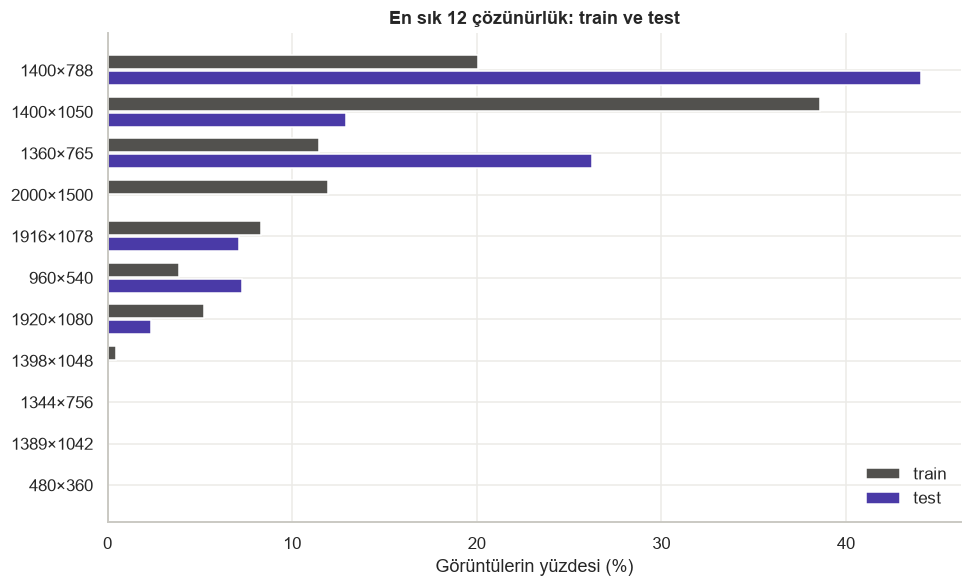

split,train,test
resolution,,
1400×788,20.10,44.10
1400×1050,38.60,12.90
1360×765,11.50,26.30
2000×1500,11.90,0.00
1916×1078,8.30,7.10
960×540,3.90,7.30
1920×1080,5.20,2.40
1398×1048,0.50,0.00
1344×756,0.00,0.00


In [7]:
res_share = (pd.crosstab(meta["resolution"], meta["split"], normalize="columns") * 100)[["train", "test"]]
res_share = res_share.loc[res_share.max(axis=1).sort_values(ascending=False).index[:12]]

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(res_share))
h = 0.38
for k, (split, off) in enumerate([("train", -h / 2), ("test", h / 2)]):
    ax.barh(y + off, res_share[split], height=h - 0.04, color=SPLIT_COLORS[split], label=split)
ax.set_yticks(y, res_share.index)
ax.invert_yaxis()
ax.set_xlabel("Görüntülerin yüzdesi (%)")
ax.set_title("En sık 12 çözünürlük: train ve test")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()
res_share.round(1)

**Ne öğrendik?**
- Çözünürlükler **heterojen**. Farklı drone ve kameralardan gelen görüntüler olabilir.
- **Test dağılımı train'den farklı.** Testte 1400×788, 1360×765 ve 960×540 görüntüler daha sık; train'de 1400×1050 baskın.
  Validation skoru test skorunu birebir yansıtmayabilir. Modelin farklı çözünürlüklere dayanıklı olması gerekiyor (çok ölçekli eğitim/augmentation).

## 5. Sınıf dağılımı

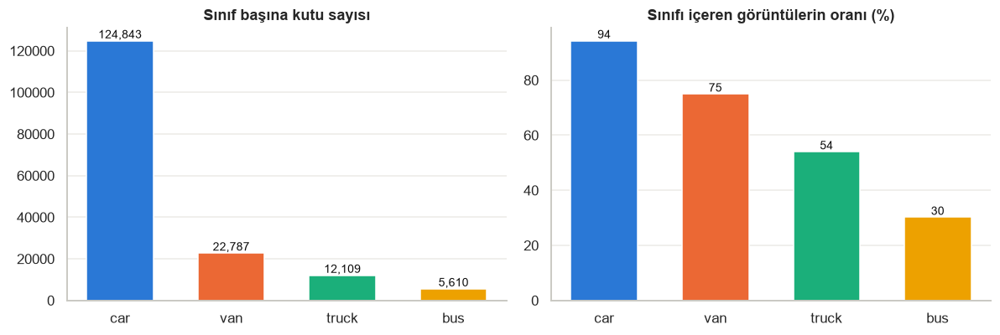

,kutu sayısı,kutu payı (%),görüldüğü görüntü,görüntülerin (%),mAP içindeki ağırlık (%)
label,,,,,
car,124843,75.50,6103,94.31,25.00
van,22787,13.78,4850,74.95,25.00
truck,12109,7.32,3494,53.99,25.00
bus,5610,3.39,1954,30.20,25.00


In [8]:
box_counts = ann["label"].value_counts().reindex(CLASSES)
img_presence = ann.groupby("label")["image_id"].nunique().reindex(CLASSES)
class_table = pd.DataFrame({
    "kutu sayısı": box_counts,
    "kutu payı (%)": box_counts / box_counts.sum() * 100,
    "görüldüğü görüntü": img_presence,
    "görüntülerin (%)": img_presence / len(train_ids) * 100,
    "mAP içindeki ağırlık (%)": 25.0,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, title in [
    (axes[0], "kutu sayısı", "Sınıf başına kutu sayısı"),
    (axes[1], "görüntülerin (%)", "Sınıfı içeren görüntülerin oranı (%)"),
]:
    vals = class_table[col]
    ax.bar(CLASSES, vals, color=[CLASS_COLORS[c] for c in CLASSES], width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color="#0b0b0b")
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
class_table

**Ne öğrendik?**
- **Kutu bazında ciddi dengesizlik var.** `car` kutuların ~%75'i, `bus` yalnızca ~%3'ü.
- mAP'te **her sınıf eşit ağırlıkta (%25)**. `bus` ve `truck`'ta alınan her AP puanı, `car`'da alınanla aynı değerde.
  Az örnekli sınıflara yönelik önlemler (oversampling, sınıf ağırlığı, copy-paste augmentation) skoru doğrudan etkiler.
- Görüntü bazında tablo daha dengeli: `truck` ve `van` görüntülerin yarısından fazlasında var. Az olan, nesne başına örnek sayısı.

## 6. Kutu geometrisi

In [9]:
ann = ann.merge(meta[["image_id", "width", "height"]], on="image_id", how="left")
ann["side"] = np.sqrt(ann["area"])                          # kutunun "eşdeğer kenar" uzunluğu
ann["min_side"] = ann[["w", "h"]].min(axis=1)
ann["aspect"] = ann["w"] / ann["h"]
ann["rel_side"] = np.sqrt(ann["area"] / (ann["width"] * ann["height"]))  # görüntüye göre göreli boyut
ann["cx"] = (ann["x"] + ann["w"] / 2) / ann["width"]
ann["cy"] = (ann["y"] + ann["h"] / 2) / ann["height"]

bounds = pd.Series({
    "x < 0 veya y < 0": int(((ann["x"] < 0) | (ann["y"] < 0)).sum()),
    "x + w > genişlik": int((ann["x"] + ann["w"] > ann["width"]).sum()),
    "y + h > yükseklik": int((ann["y"] + ann["h"] > ann["height"]).sum()),
    "Görüntü kenarına değen kutu": int(((ann["x"] <= 0) | (ann["y"] <= 0) |
                                         (ann["x"] + ann["w"] >= ann["width"]) |
                                         (ann["y"] + ann["h"] >= ann["height"])).sum()),
}, name="adet")
bounds.to_frame()

,adet
x < 0 veya y < 0,0
x + w > genişlik,0
y + h > yükseklik,0
Görüntü kenarına değen kutu,7937


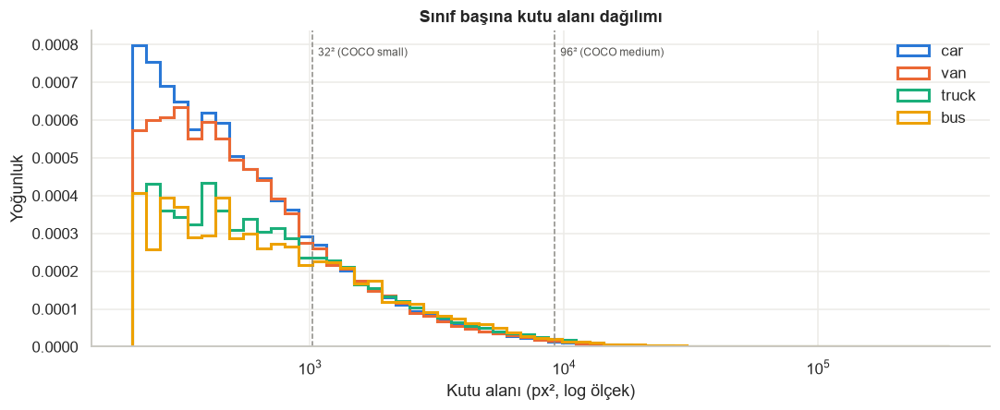

,count,mean,std,min,10%,25%,50%,75%,90%,max
label,,,,,,,,,,
car,"124,843.00","3,799.39","7,325.78",200.00,341.00,616.00,"1,472.00","3,922.00","8,910.00","328,640.00"
van,"22,787.00","4,494.03","9,224.70",200.00,364.00,660.00,"1,599.00","4,459.00","10,560.00","257,312.00"
truck,"12,109.00","6,875.46","15,098.11",200.00,460.00,952.00,"2,409.00","6,630.00","15,369.60","315,202.00"
bus,"5,610.00","7,357.91","17,716.75",200.00,495.00,"1,073.50","2,648.00","6,499.00","15,729.10","324,300.00"


In [10]:
bins = np.logspace(np.log10(MIN_AREA), np.log10(ann["area"].max()), 60)
fig, ax = plt.subplots(figsize=(10, 4.2))
for c in CLASSES:
    ax.hist(ann.loc[ann["label"] == c, "area"], bins=bins, density=True,
            histtype="step", linewidth=2, color=CLASS_COLORS[c], label=c)
for thr, name in [(32**2, "32² (COCO small)"), (96**2, "96² (COCO medium)")]:
    ax.axvline(thr, color="#8a8984", linestyle="--", linewidth=1)
    ax.text(thr * 1.05, ax.get_ylim()[1] * 0.92, name, fontsize=8, color="#52514e")
ax.set_xscale("log")
ax.set_xlabel("Kutu alanı (px², log ölçek)")
ax.set_ylabel("Yoğunluk")
ax.set_title("Sınıf başına kutu alanı dağılımı")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

ann.groupby("label")["area"].describe(percentiles=[.1, .25, .5, .75, .9]).reindex(CLASSES)

In [11]:
size_bins = [MIN_AREA, 16**2 * 2, 32**2, 64**2, 96**2, np.inf]
size_labels = ["200–512", "512–1024 (≤32²)", "1024–4096", "4096–9216 (≤96²)", "> 9216"]
ann["size_bin"] = pd.cut(ann["area"], bins=size_bins, labels=size_labels, right=False)
size_tab = pd.crosstab(ann["label"], ann["size_bin"], normalize="index").reindex(CLASSES) * 100
size_tab["Tümü: COCO small (<32²) %"] = (ann.assign(s=ann["area"] < 32**2)
                                          .groupby("label")["s"].mean().reindex(CLASSES) * 100)
size_tab.round(1)

size_bin,200–512,512–1024 (≤32²),1024–4096,4096–9216 (≤96²),> 9216,Tümü: COCO small (<32²) %
label,,,,,,
car,20.00,19.90,36.10,14.50,9.60,39.90
van,18.00,19.60,35.70,14.90,11.80,37.60
truck,11.70,14.90,37.40,18.20,17.90,26.60
bus,10.70,13.20,38.50,19.70,17.80,23.90


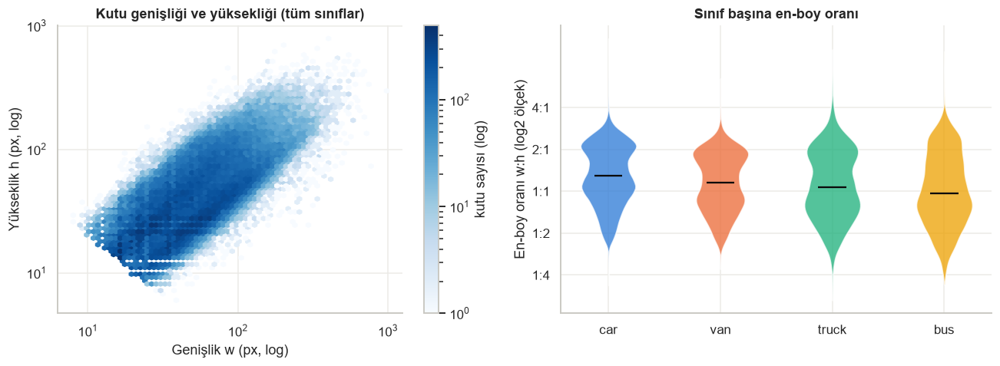

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

hb = axes[0].hexbin(ann["w"], ann["h"], gridsize=70, bins="log", cmap="Blues",
                    xscale="log", yscale="log", mincnt=1)
axes[0].set_xlabel("Genişlik w (px, log)")
axes[0].set_ylabel("Yükseklik h (px, log)")
axes[0].set_title("Kutu genişliği ve yüksekliği (tüm sınıflar)")
fig.colorbar(hb, ax=axes[0], label="kutu sayısı (log)")

data = [np.log2(ann.loc[ann["label"] == c, "aspect"]) for c in CLASSES]
parts = axes[1].violinplot(data, showmedians=True, showextrema=False)
for body, c in zip(parts["bodies"], CLASSES):
    body.set_facecolor(CLASS_COLORS[c])
    body.set_alpha(0.75)
parts["cmedians"].set_color("#0b0b0b")
axes[1].set_xticks(range(1, 5), CLASSES)
axes[1].set_yticks([-2, -1, 0, 1, 2], ["1:4", "1:2", "1:1", "2:1", "4:1"])
axes[1].set_ylabel("En-boy oranı w:h (log2 ölçek)")
axes[1].set_title("Sınıf başına en-boy oranı")
plt.tight_layout()
plt.show()

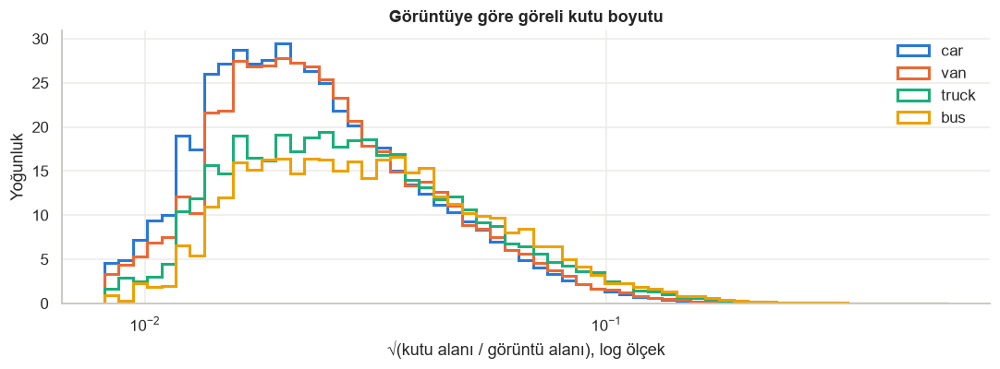

count   165,349.00
mean          0.04
std           0.03
min           0.01
10%           0.02
50%           0.03
90%           0.08
max           0.55
Name: rel_side, dtype: float64

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.8))
rbins = np.logspace(np.log10(ann["rel_side"].min()), np.log10(ann["rel_side"].max()), 60)
for c in CLASSES:
    ax.hist(ann.loc[ann["label"] == c, "rel_side"], bins=rbins, density=True,
            histtype="step", linewidth=2, color=CLASS_COLORS[c], label=c)
ax.set_xscale("log")
ax.set_xlabel("√(kutu alanı / görüntü alanı), log ölçek")
ax.set_ylabel("Yoğunluk")
ax.set_title("Görüntüye göre göreli kutu boyutu")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
ann["rel_side"].describe(percentiles=[.1, .5, .9])

**Ne öğrendik?**
- **Nesnelerin çoğu küçük.** `car` kutularının büyük kısmı COCO tanımına göre "small" (<32×32). Tipik bir araç görüntü kenarının yalnızca birkaç yüzdesi kadar.
- `bus` ve `truck` ortalamada daha büyük ama dağılımları geniş. Uzaktaki otobüsler, yakındaki arabalardan küçük olabiliyor, yani **boyut tek başına ayırt edici değil**.
- En-boy oranı sınıfa göre fazla değişmiyor (drone açısıyla araç her yöne dönük olabilir). `bus`/`truck` biraz daha uzun.
- Görüntü kenarına değen (kesik) kutular var. Tiling yaparken tile sınırında kesilen nesneleri doğru yönetmek gerekecek.

## 7. Görüntü başına nesne yoğunluğu ve sınıf birlikteliği

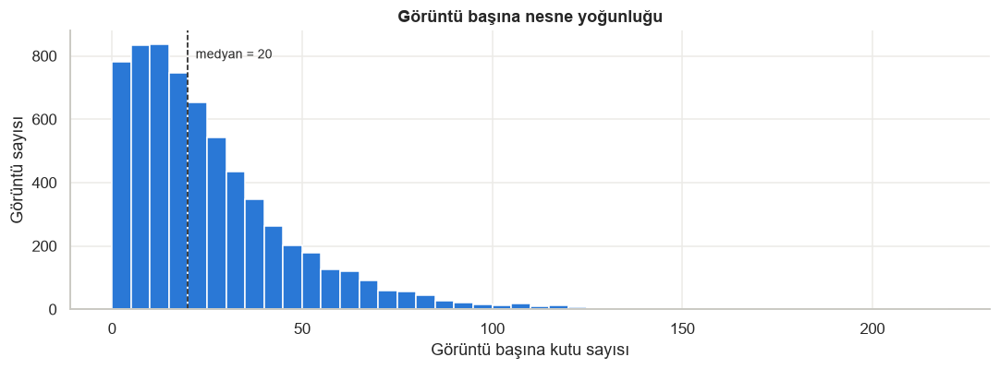

,count,mean,std,min,50%,90%,99%,max
label,,,,,,,,
car,"6,471.00",19.29,19.15,0.00,14.00,43.00,91.00,199.00
van,"6,471.00",3.52,5.02,0.00,2.00,8.00,23.00,80.00
truck,"6,471.00",1.87,3.44,0.00,1.00,5.00,16.00,60.00
bus,"6,471.00",0.87,2.64,0.00,0.00,2.00,12.00,45.00
total,"6,471.00",25.55,23.01,0.00,20.00,55.00,108.00,218.00


In [14]:
per_img = (ann.groupby(["image_id", "label"]).size().unstack(fill_value=0)
              .reindex(columns=CLASSES, fill_value=0)
              .reindex(train_ids, fill_value=0))
per_img["total"] = per_img[CLASSES].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.hist(per_img["total"], bins=np.arange(0, per_img["total"].max() + 5, 5), color="#2a78d6",
        edgecolor="white", linewidth=1)
med = per_img["total"].median()
ax.axvline(med, color="#0b0b0b", linestyle="--", linewidth=1)
ax.text(med + 2, ax.get_ylim()[1] * 0.9, f"medyan = {med:.0f}", fontsize=9)
ax.set_xlabel("Görüntü başına kutu sayısı")
ax.set_ylabel("Görüntü sayısı")
ax.set_title("Görüntü başına nesne yoğunluğu")
plt.tight_layout()
plt.show()
per_img.describe(percentiles=[.5, .9, .99]).T

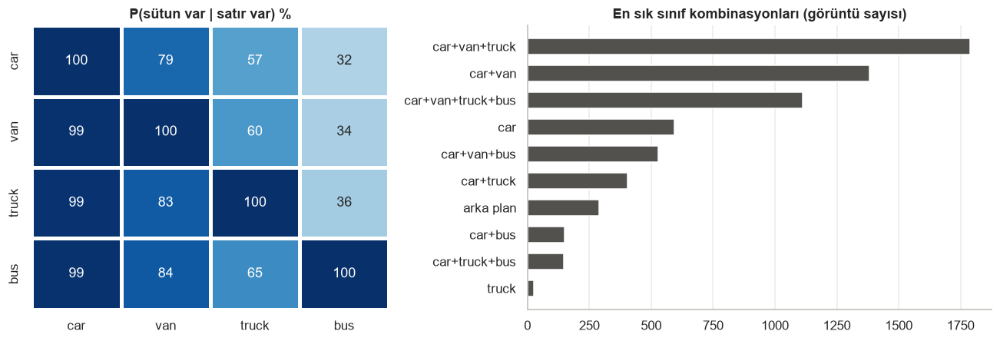

In [15]:
present = per_img[CLASSES] > 0
# P(sütun sınıfı var | satır sınıfı var)
cooc = pd.DataFrame({b: [(present[a] & present[b]).sum() / present[a].sum() for a in CLASSES]
                     for b in CLASSES}, index=CLASSES) * 100
combo = present.apply(lambda r: "+".join(c for c in CLASSES if r[c]) or "arka plan", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})
sns.heatmap(cooc, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=False,
            linewidths=2, linecolor="white", ax=axes[0])
axes[0].set_title("P(sütun var | satır var) %")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

top_combo = combo.value_counts().head(10)[::-1]
axes[1].barh(top_combo.index, top_combo.values, color="#52514e", height=0.6)
axes[1].set_title("En sık sınıf kombinasyonları (görüntü sayısı)")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Görüntüler **kalabalık**: medyan ~20 kutu, en yoğun görüntülerde 200'ün üzerinde. Inference'ta `max_det` en az 300 olmalı; varsayılan limit kutu kaybettirebilir.
- Sınıflar genellikle birlikte görülüyor (trafik sahneleri). `bus` veya `truck` içeren görüntülerin neredeyse hepsinde `car` da var.
  Nadir sınıfı oversample etmek otomatik olarak `car` örneklerini de çoğaltır; bu yüzden görüntü tekrarı yerine **nesne düzeyinde augmentation** (copy-paste) daha hedefli olabilir.

## 8. Uzamsal dağılım

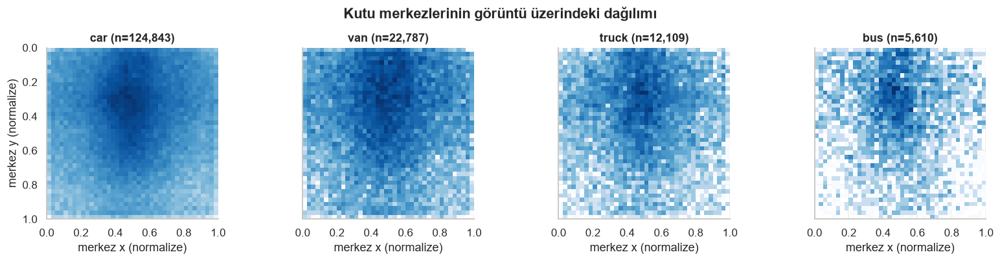

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, c in zip(axes, CLASSES):
    sub = ann[ann["label"] == c]
    ax.hist2d(sub["cx"], sub["cy"], bins=40, range=[[0, 1], [0, 1]], cmap="Blues", norm=LogNorm())
    ax.set_title(f"{c} (n={len(sub):,})")
    ax.set_xlabel("merkez x (normalize)")
    ax.set_aspect("equal")
axes[0].invert_yaxis()  # sharey=True: tek eksende çevirmek hepsine uygulanır; y=0 görüntünün üstü
axes[0].set_ylabel("merkez y (normalize)")
fig.suptitle("Kutu merkezlerinin görüntü üzerindeki dağılımı", fontweight="bold")
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Nesneler görüntünün her yerinde, ama yoğunluk **merkezde ve merkezin biraz üstünde** (y ≈ 0.3–0.4) toplanıyor. Kenarlar, özellikle alt kenar, daha seyrek.
  Kamera yolu/kavşağı kadrajın ortasına alacak şekilde yönlendirilmiş gibi görünüyor.
- Konuma dayalı bir kısa yol yok. **Yatay çevirme** güvenli bir augmentation, dikey çevirme de kuşbakışı çekimler için makul.
  Mosaic/random-crop gibi augmentation'lar nesneleri kenarlara da taşıyarak bu merkez eğilimini dengeler.

## 9. Görsel örnekler
Sayılar önemli ama veriyi gözle görmek şart. Renkler: <span style="color:#2a78d6">■ car</span>
<span style="color:#eb6834">■ van</span> <span style="color:#1baf7a">■ truck</span> <span style="color:#eda100">■ bus</span>

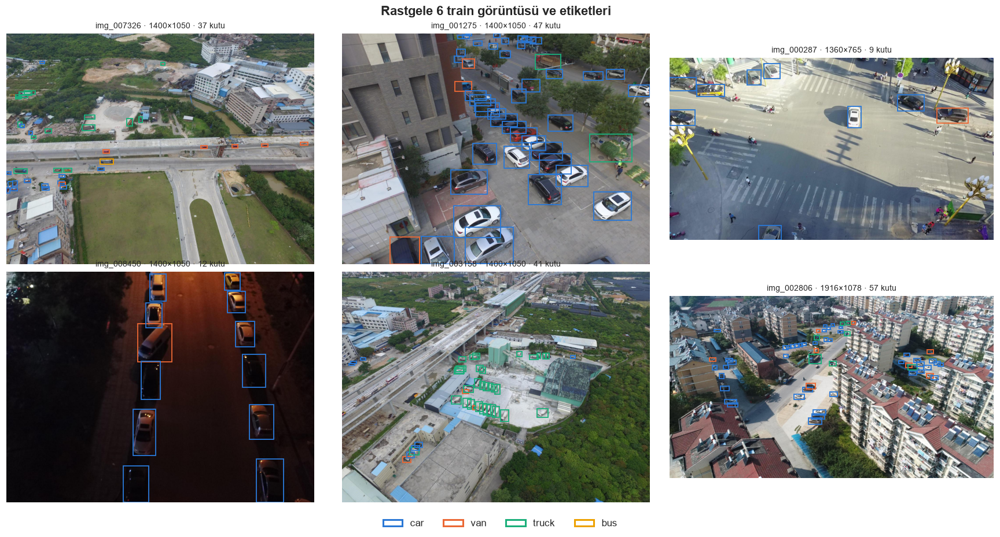

In [17]:
ann_by_img = {k: g for k, g in ann.groupby("image_id")}
rng = random.Random(SEED)


def show_image(image_id, ax, folder=TRAIN_IMG_DIR, boxes=True):
    img = Image.open(folder / f"{image_id}.jpg")
    ax.imshow(img)
    if boxes and image_id in ann_by_img:
        for r in ann_by_img[image_id].itertuples():
            ax.add_patch(mpatches.Rectangle((r.x, r.y), r.w, r.h, fill=False,
                                            edgecolor=CLASS_COLORS[r.label], linewidth=1.2))
    n = len(ann_by_img.get(image_id, [])) if boxes else None
    ax.set_title(f"{image_id} · {img.size[0]}×{img.size[1]}" + (f" · {n} kutu" if n is not None else ""),
                 fontsize=9, fontweight="normal")
    ax.axis("off")


legend_handles = [mpatches.Patch(facecolor="none", edgecolor=CLASS_COLORS[c], linewidth=2, label=c) for c in CLASSES]

sample_ids = rng.sample(sorted(ann_by_img), 6)
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, i in zip(axes.flat, sample_ids):
    show_image(i, ax)
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
fig.suptitle("Rastgele 6 train görüntüsü ve etiketleri", fontweight="bold")
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

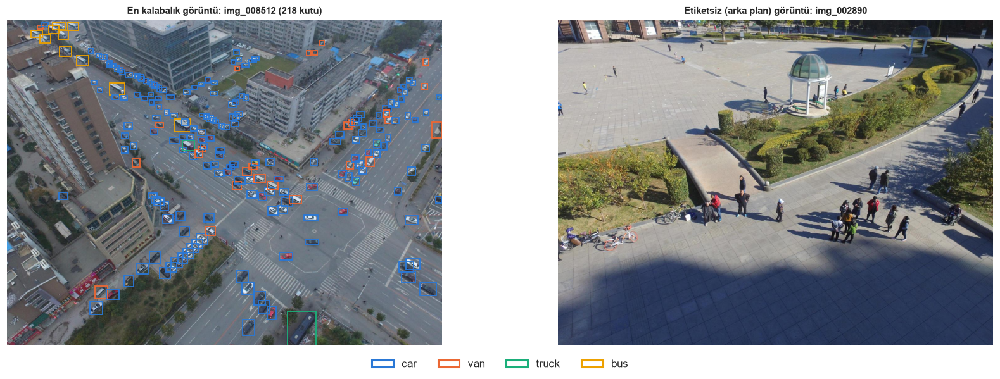

In [18]:
crowded = per_img["total"].idxmax()
background = rng.choice(sorted(set(train_ids) - set(ann_by_img)))
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
show_image(crowded, axes[0])
axes[0].set_title(f"En kalabalık görüntü: {crowded} ({per_img.loc[crowded, 'total']} kutu)", fontsize=10)
show_image(background, axes[1])
axes[1].set_title(f"Etiketsiz (arka plan) görüntü: {background}", fontsize=10)
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

### Sınıf bazında kırpılmış örnekler
Özellikle **car ve van** ile **truck ve bus** ayrımı zor olabilir. Her sınıftan orta boy (medyan alan civarı) örnekleri yan yana koyuyoruz.
Her kırpıntıya biraz bağlam payı eklendi, çerçeve etiket kutusunu gösteriyor.

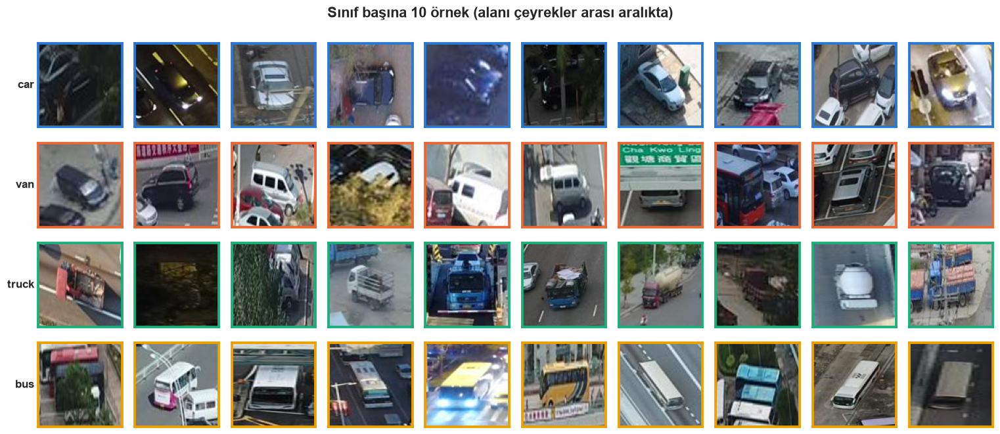

In [19]:
def crop(r, pad=0.35, thumb=96, mark=False):
    img = Image.open(TRAIN_IMG_DIR / f"{r.image_id}.jpg").convert("RGB")
    px, py = r.w * pad, r.h * pad
    box = tuple(int(v) for v in (max(0, r.x - px), max(0, r.y - py),
                                  min(r.width, r.x + r.w + px), min(r.height, r.y + r.h + py)))
    if mark:  # hedef nesneyi kırpıntı içinde işaretle (bağlamdaki diğer araçlardan ayırmak için)
        ImageDraw.Draw(img).rectangle((r.x - 1, r.y - 1, r.x + r.w, r.y + r.h), outline=CLASS_COLORS[r.label], width=1)
    return img.crop(box).resize((thumb, thumb))


N = 10
fig, axes = plt.subplots(len(CLASSES), N, figsize=(N * 1.4, len(CLASSES) * 1.55))
for row, c in enumerate(CLASSES):
    sub = ann[(ann["label"] == c)]
    q25, q75 = sub["area"].quantile([.25, .75])
    picks = sub[(sub["area"] >= q25) & (sub["area"] <= q75)].sample(N, random_state=SEED)
    for col, r in enumerate(picks.itertuples()):
        ax = axes[row, col]
        ax.imshow(crop(r))
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(CLASS_COLORS[c])
            s.set_linewidth(2.5)
    axes[row, 0].set_ylabel(c, rotation=0, ha="right", va="center", fontsize=11, fontweight="bold")
fig.suptitle("Sınıf başına 10 örnek (alanı çeyrekler arası aralıkta)", fontweight="bold")
plt.tight_layout()
plt.show()

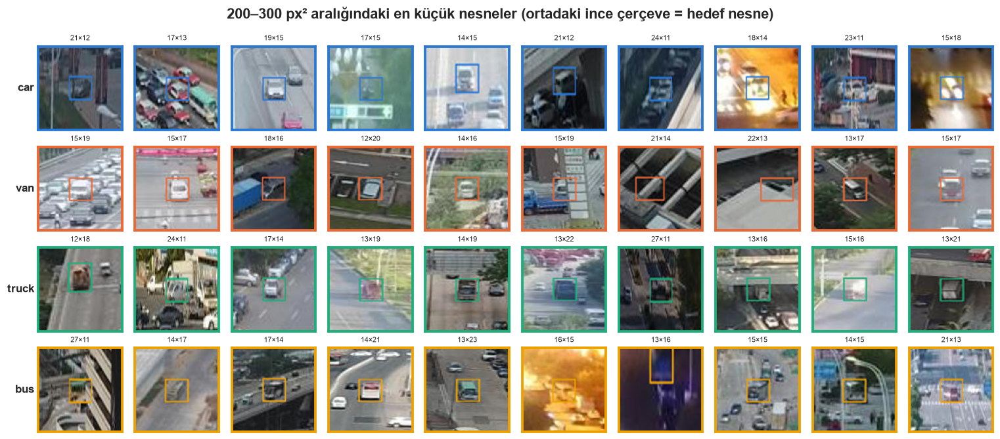

In [20]:
# Eşiğe yakın, en küçük etiketli nesneler: model neyi görmek zorunda?
fig, axes = plt.subplots(len(CLASSES), N, figsize=(N * 1.4, len(CLASSES) * 1.55))
for row, c in enumerate(CLASSES):
    picks = ann[(ann["label"] == c) & (ann["area"] < 300)].sample(N, random_state=SEED)
    for col, r in enumerate(picks.itertuples()):
        ax = axes[row, col]
        ax.imshow(crop(r, pad=1.5, mark=True))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{r.w}×{r.h}", fontsize=7, fontweight="normal")
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_edgecolor(CLASS_COLORS[c])
            s.set_linewidth(2.5)
    axes[row, 0].set_ylabel(c, rotation=0, ha="right", va="center", fontsize=11, fontweight="bold")
fig.suptitle("200–300 px² aralığındaki en küçük nesneler (ortadaki ince çerçeve = hedef nesne)", fontweight="bold")
plt.tight_layout()
plt.show()

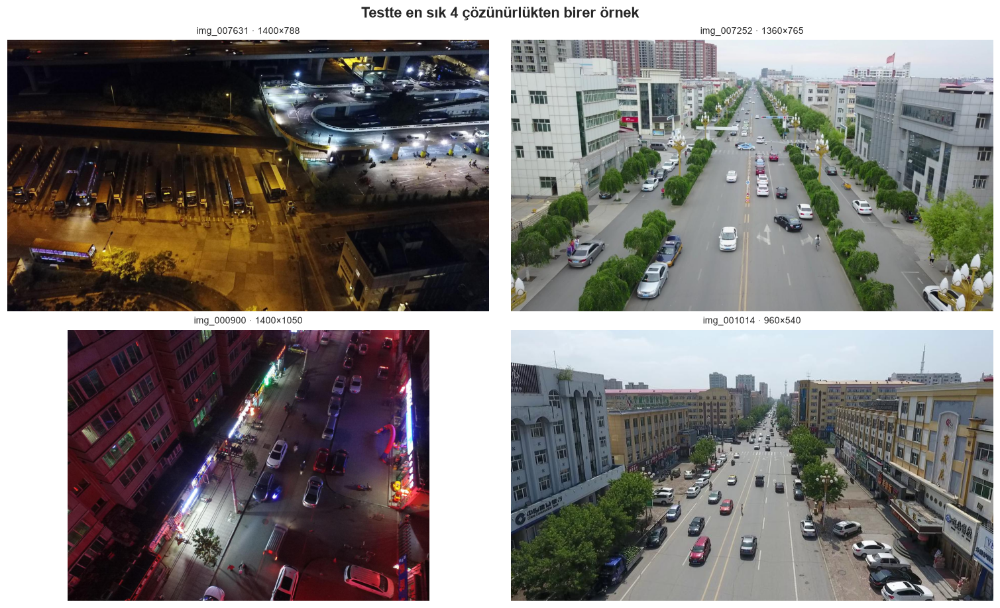

In [21]:
# Test görüntüleri: özellikle train'de az görülen çözünürlüklerden örnekler (etiket yok)
test_meta = meta[meta["split"] == "test"]
test_samples = [test_meta[test_meta["resolution"] == res]["image_id"].sample(1, random_state=SEED).iloc[0]
                for res in test_meta["resolution"].value_counts().index[:4]]
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, i in zip(axes.flat, test_samples):
    show_image(i, ax, folder=TEST_IMG_DIR, boxes=False)
fig.suptitle("Testte en sık 4 çözünürlükten birer örnek", fontweight="bold")
plt.tight_layout()
plt.show()

**Ne öğrendik?**
- Görüntüler farklı irtifa ve açılardan çekilmiş: dik kuşbakışı ve eğik çekimler, gündüz ve düşük ışık sahneleri bir arada.
- Eşiğe yakın nesneler yalnızca birkaç piksel genişliğinde ve **sınıfı çıplak gözle bile zor seçiliyor**. Bu nesnelerde model güveni düşük olacak.
  mAP sıralama tabanlı olduğu için düşük güvenli tahminleri silmek yerine göndermek doğru.
- Küçük nesnelerin çevresinde **etiketsiz araçlar** görülebiliyor (200 px² altında kalanlar). Model bunları eğitimde "arka plan" olarak öğreniyor; bu durum küçük nesnelerde recall'ı bir miktar baskılayabilir.
- `van` ile `car` görsel olarak çok yakın. Karışıklık matrisinde en çok bu çifti izlemeliyiz.

## 10. Paylaşılan train/validation split'inin kontrolü

In [22]:
split_meta = json.loads((SPLITS / "metadata.json").read_text())
sha = hashlib.sha256((DATA / "train" / "annotations.csv").read_bytes()).hexdigest()
tr_ids = (SPLITS / "train.txt").read_text().split()
va_ids = (SPLITS / "val.txt").read_text().split()

pd.Series({
    "annotations.csv checksum eşleşiyor": sha == split_meta["annotations_sha256"],
    "train ∩ val boş": not (set(tr_ids) & set(va_ids)),
    "train ∪ val = tüm train görüntüleri": set(tr_ids) | set(va_ids) == set(train_ids),
    "train / val görüntü sayısı": f"{len(tr_ids)} / {len(va_ids)}",
}, name="sonuç").to_frame()

,sonuç
annotations.csv checksum eşleşiyor,True
train ∩ val boş,True
train ∪ val = tüm train görüntüleri,True
train / val görüntü sayısı,5177 / 1294


In [23]:
split_of = {**{i: "train" for i in tr_ids}, **{i: "val" for i in va_ids}}
ann["split"] = ann["image_id"].map(split_of)
cmp = pd.DataFrame({
    "train kutu %": ann[ann["split"] == "train"]["label"].value_counts(normalize=True) * 100,
    "val kutu %": ann[ann["split"] == "val"]["label"].value_counts(normalize=True) * 100,
    "train medyan alan": ann[ann["split"] == "train"].groupby("label")["area"].median(),
    "val medyan alan": ann[ann["split"] == "val"].groupby("label")["area"].median(),
}).reindex(CLASSES)

meta["split2"] = meta["image_id"].map(split_of).fillna("test")
res_cmp = (pd.crosstab(meta["resolution"], meta["split2"], normalize="columns") * 100)[["train", "val", "test"]]
res_cmp = res_cmp.loc[res_cmp.max(axis=1).sort_values(ascending=False).index[:8]]
display(cmp.round(1))
res_cmp.round(1)

,train kutu %,val kutu %,train medyan alan,val medyan alan
label,,,,
car,75.40,75.80,"1,470.00","1,485.00"
van,13.80,13.50,"1,566.00","1,740.00"
truck,7.40,7.10,"2,432.00","2,325.00"
bus,3.30,3.60,"2,693.00","2,492.50"


split2,train,val,test
resolution,,,
1400×788,19.70,21.60,44.10
1400×1050,39.00,37.10,12.90
1360×765,11.50,11.30,26.30
2000×1500,11.80,12.30,0.00
1916×1078,8.40,7.70,7.10
960×540,3.70,4.60,7.30
1920×1080,5.30,5.20,2.40
1398×1048,0.50,0.20,0.00


**Ne öğrendik?**
- Split, sınıf dağılımı ve nesne boyutu açısından dengeli. Takımın ortak benchmark'ı olarak güvenle kullanılabilir.
- Val'in çözünürlük dağılımı train'e benziyor, **teste değil**. Val skoru teste göre biraz iyimser olabilir.
  Yerel değerlendirmede ek olarak **çözünürlük bazında mAP** (özellikle testte sık olan 1400×788 / 1360×765 / 960×540 grupları) raporlamak faydalı.

## 11. Yeniden boyutlandırmanın küçük nesnelere etkisi
YOLO benzeri modeller görüntüyü uzun kenarı `imgsz` olacak şekilde küçültür (letterbox). Bir aracın kenarı birkaç pikselin altına düşerse
model onu pratikte göremez. Farklı `imgsz` değerlerinde kısa kenarı **8 px** ve **16 px**'in altına düşen kutuların oranına bakalım.

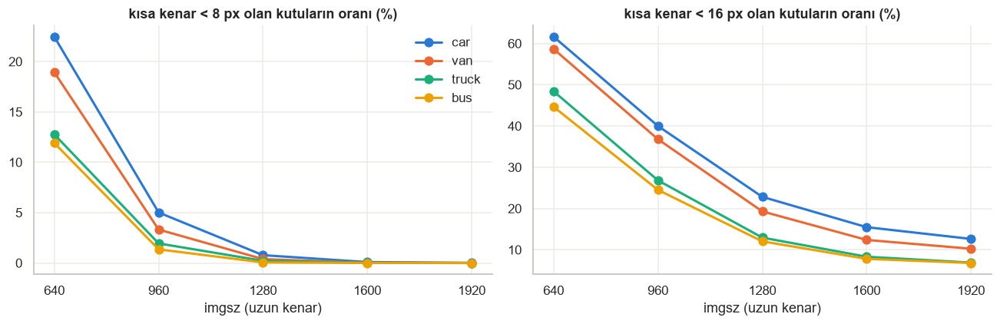

sınıf,car,van,truck,bus,tümü
imgsz,,,,,
640,61.60,58.70,48.40,44.60,59.70
960,40.00,36.80,26.80,24.50,38.10
1280,22.80,19.30,12.90,12.00,21.20
1600,15.50,12.40,8.30,7.80,14.30
1920,12.60,10.20,6.90,6.80,11.70


In [24]:
rows = []
long_side = ann[["width", "height"]].max(axis=1)
for imgsz in [640, 960, 1280, 1600, 1920]:
    scale = np.minimum(1.0, imgsz / long_side)  # büyütme yapılmadığını varsay
    ms = ann["min_side"] * scale
    for c in CLASSES + ["tümü"]:
        m = (ann["label"] == c) if c != "tümü" else slice(None)
        rows.append({"imgsz": imgsz, "sınıf": c,
                     "kısa kenar < 8 px (%)": (ms[m] < 8).mean() * 100,
                     "kısa kenar < 16 px (%)": (ms[m] < 16).mean() * 100})
resize_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, col in zip(axes, ["kısa kenar < 8 px (%)", "kısa kenar < 16 px (%)"]):
    for c in CLASSES:
        d = resize_df[resize_df["sınıf"] == c]
        ax.plot(d["imgsz"], d[col], marker="o", markersize=7, linewidth=2, color=CLASS_COLORS[c], label=c)
    ax.set_xticks([640, 960, 1280, 1600, 1920])
    ax.set_xlabel("imgsz (uzun kenar)")
    ax.set_title(col.replace(" (%)", "") + " olan kutuların oranı (%)")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()
resize_df.pivot(index="imgsz", columns="sınıf", values="kısa kenar < 16 px (%)")[CLASSES + ["tümü"]].round(1)

**Ne öğrendik?**
- 640 piksel girişte kutuların önemli bir kısmı çok küçük hâle geliyor. **Çözünürlüğü artırmak, bu veri setinde muhtemelen en etkili tek iyileştirme.**
- 1280'e çıkmak kaybın çoğunu geri kazandırıyor; bunun ötesi GPU belleğiyle dengelenmeli. Alternatif olarak **tiling (SAHI)** ile orijinal çözünürlükte çalışılabilir.

## 12. Bulgular → Modelleme kararları

| # | Bulgu | Sayı | Karar |
|---|---|---|---|
| 1 | Nesneler çok küçük | car kutularının %40'ı, tüm kutuların ~%38'i < 32×32 px; medyan car alanı ~1.470 px² (~38×38) | **Yüksek çözünürlükle eğitim ve inference.** `imgsz=1280` başlangıç, 1600+ ve/veya SAHI tiling denenecek. |
| 2 | 640'a küçültmek küçük nesneleri siliyor | imgsz=640'ta kutuların ~%60'ının kısa kenarı < 16 px; 1280'de ~%21, 1600'de ~%14 | 640 ile baseline kurmayacağız; ilk deney doğrudan 1280. |
| 3 | Sınıf dengesizliği | car %75.5 · van %13.8 · truck %7.3 · bus %3.4 (kutu) | mAP'te her sınıf %25. **Sınıf bazında AP izlenecek.** bus/truck için oversampling, copy-paste veya sınıf ağırlığı denenecek. |
| 4 | Sınıflar birlikte görülüyor | bus içeren görüntülerin %99'unda car da var | Görüntü tekrarı car'ı da çoğaltır. Nesne düzeyinde augmentation daha hedefli. |
| 5 | Kalabalık sahneler | Görüntü başına medyan 20, maks. 218 kutu | Inference'ta `max_det ≥ 300`, `conf ≈ 0.001` (mAP düşük güvenli tahminleri cezalandırmaz). |
| 6 | Train ve test çözünürlük dağılımı farklı | Test: 1400×788 %44, 1360×765 %26; train'de 1400×1050 %39 baskın, 2000×1500 testte hiç yok | Çok ölçekli eğitim (`scale` aug). Val'de **çözünürlük grubuna göre mAP** raporlanacak. |
| 7 | car ve van görsel olarak çok yakın | Crop galerisi | Confusion matrix ile car↔van karışıklığı izlenecek. |
| 8 | Arka plan görüntüleri var | 290 görüntü (%4.5) | Eğitimde boş etiketle tutulacak (yanlış pozitifleri azaltır). |
| 9 | Etiketsiz küçük araçlar (< 200 px²) | Görsellerde net | Tahmin tarafında puanı etkilemiyor, filtrelemeye gerek yok. Eğitimde şimdilik olduğu gibi bırakılacak. |
| 10 | Veri temiz | 0 eksik, 1 tekrar eden satır, sınır dışı kutu yok | YOLO formatına dönüştürürken tekrar eden satır atılacak. Başka temizlik gerekmiyor. |
| 11 | Paylaşılan split sağlam | checksum eşleşiyor, sınıf dağılımı train ≈ val | Tüm deneyler `splits/train.txt` / `splits/val.txt` ile karşılaştırılacak. |

**Sonraki adımlar**
1. `02_prepare_yolo.ipynb`: CSV'yi YOLO formatına dönüştürmek (split'e göre, arka plan görüntüleri dahil).
2. Kaggle metriğini taklit eden yerel mAP@0.5 değerlendirici ve submission format doğrulayıcı.
3. Baseline: YOLO11m, `imgsz=1280`, COCO ön-eğitimli ağırlıklar (Kaggle GPU).